In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [4]:
data= pd.read_csv('dataset.csv')

df=pd.DataFrame(data)

df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0
5,32257,Female,47.0,0,0,Yes,Private,Urban,210.95,50.1,NaN,0
6,52800,Female,52.0,0,0,Yes,Private,Urban,77.59,17.7,formerly smoked,0
7,41413,Female,75.0,0,1,Yes,Self-employed,Rural,243.53,27.0,never smoked,0
8,15266,Female,32.0,0,0,Yes,Private,Rural,77.67,32.3,smokes,0
9,28674,Female,74.0,1,0,Yes,Self-employed,Urban,205.84,54.6,never smoked,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43400 non-null  int64  
 1   gender             43400 non-null  object 
 2   age                43400 non-null  float64
 3   hypertension       43400 non-null  int64  
 4   heart_disease      43400 non-null  int64  
 5   ever_married       43400 non-null  object 
 6   work_type          43400 non-null  object 
 7   Residence_type     43400 non-null  object 
 8   avg_glucose_level  43400 non-null  float64
 9   bmi                41938 non-null  float64
 10  smoking_status     30108 non-null  object 
 11  stroke             43400 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 4.0+ MB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.shape #عدد الصفوف والاعمدة

(43400, 12)

In [10]:
df.isna().sum() #فحص القيم المفقودة

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,1462


In [11]:
df['stroke'].value_counts()

,count
stroke,
0,42617
1,783


تصوير توزيع البيانات

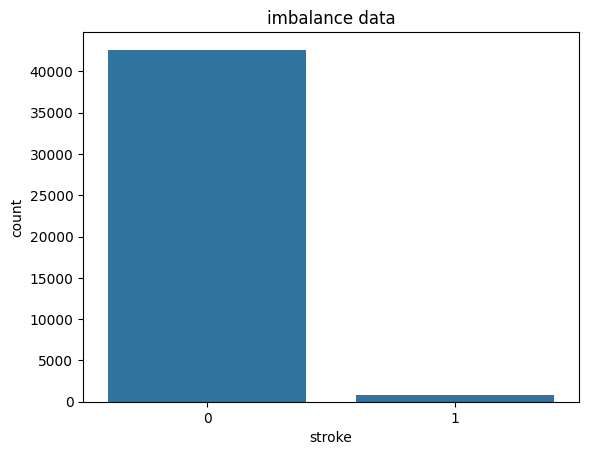

In [12]:
sns.countplot(x='stroke',data=df)
plt.title("imbalance data")
plt.show()

In [13]:
df = pd.DataFrame(data)

# 1. تنظيف القيم المفقودة
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())
df['smoking_status'] = df['smoking_status'].fillna('Unknown')

# One-Hot Encoding
categorical_columns = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True, dtype=int)

# العمر
df['is_senior'] = (df['age'] > 60).astype(int)

# اكبر من 30 سمنة
df['is_obese'] = (df['bmi'] > 30).astype(int)

# نحذف stroke التي نريد التنبؤ بها
X = df.drop('stroke', axis=1)
y = df['stroke']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# معالجة عدم التوازن
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())

stroke
0    34098
1    34098
Name: count, dtype: int64


In [14]:
from sklearn.preprocessing import StandardScaler
Scaler=StandardScaler()
X_train=Scaler.fit_transform(X_train)
X_test=Scaler.transform(X_test)

logistic regression model

In [15]:
from sklearn.linear_model import LogisticRegression
logistic=LogisticRegression(max_iter=10000)

In [ ]:
logistic.fit(X_train,y_train)

LogisticRegression(max_iter=10000)

In [ ]:
# توقع ناتج بيانات الاختبار
y_pred = logistic.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# حساب المقاييس
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_rep = classification_report(y_test, y_pred)

# طباعة النتائج
print(f"Accuracy: {accuracy}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_rep)

Accuracy: 0.878110599078341

Confusion Matrix:
[[7576  943]
 [ 115   46]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.93      8519
           1       0.05      0.29      0.08       161

    accuracy                           0.88      8680
   macro avg       0.52      0.59      0.51      8680
weighted avg       0.97      0.88      0.92      8680



In [ ]:
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier()

In [ ]:
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
#توقع الناتج
y_pred_dt = decision_tree.predict(X_test)

In [ ]:
#حساب المقاييس
accuracy_dt = accuracy_score(y_test, y_pred_dt)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
classification_rep_dt = classification_report(y_test, y_pred_dt)
#طباعة النتائج
print(f"Accuracy: {accuracy_dt}")
print("\nConfusion Matrix:")
print(conf_matrix_dt)
print("\nClassification Report:")
print(classification_rep_dt)

Accuracy: 0.9341013824884793

Confusion Matrix:
[[8090  429]
 [ 143   18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      8519
           1       0.04      0.11      0.06       161

    accuracy                           0.93      8680
   macro avg       0.51      0.53      0.51      8680
weighted avg       0.97      0.93      0.95      8680



In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [18]:
# انشاء موديل
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [19]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
# استخدام الموديل المدرب لتوقع النتائج من بيانات الاختبار
y_pred = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy_rf = accuracy_score(y_test, y_pred)
conf_matrix_rf = confusion_matrix(y_test, y_pred)
classification_rep_rf = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy_rf}")
print("\nConfusion Matrix:")
print(conf_matrix_rf)
print("\nClassification Report:")
print(classification_rep_rf)

Accuracy: 0.9573732718894009

Confusion Matrix:
[[8300  219]
 [ 151   10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      8519
           1       0.04      0.06      0.05       161

    accuracy                           0.96      8680
   macro avg       0.51      0.52      0.51      8680
weighted avg       0.96      0.96      0.96      8680



In [ ]:
from xgboost import XGBClassifier

# تعريف وتدريب النموذج
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# توقع النتائج
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
# حساب المقاييس
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
classification_rep_xgb = classification_report(y_test, y_pred_xgb)

In [ ]:
print(f"Accuracy: {accuracy_xgb}")
print("\nConfusion Matrix:")
print(conf_matrix_xgb)
print("\nClassification Report:")
print(classification_rep_xgb)

Accuracy: 0.9369815668202764

Confusion Matrix:
[[8114  405]
 [ 142   19]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      8519
           1       0.04      0.12      0.06       161

    accuracy                           0.94      8680
   macro avg       0.51      0.54      0.52      8680
weighted avg       0.97      0.94      0.95      8680



مقارنة دقة النماذج

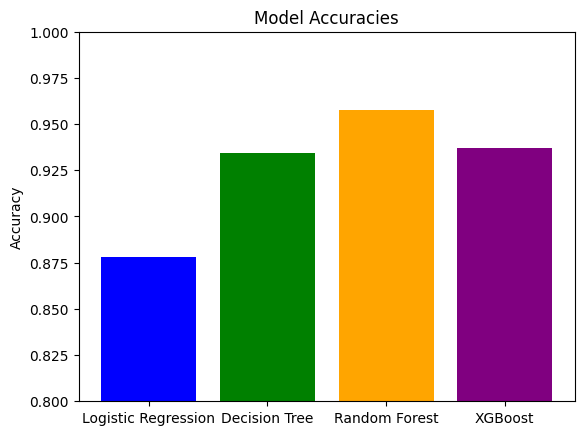

In [ ]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

accuracies = [accuracy, accuracy_dt, accuracy_rf, accuracy_xgb]
plt.bar(models, accuracies, color=['blue', 'green', 'orange', 'purple'])

plt.ylabel('Accuracy')
plt.title('Model Accuracies')
plt.ylim(0.8, 1.0)
plt.show()

In [21]:
import pickle

# تأكد من تشغيل خلايا تدريب rf_model و Scaler أولاً
pickle.dump(rf_model, open('stroke_model.sav', 'wb'))

pickle.dump(Scaler, open('scaler.sav', 'wb'))